In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv("epstein_email_threads_export.csv")
text = df.to_string()

# pattern = r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}'
# pattern = r'''
# \b(
# \d{1,2}/\d{1,2}/\d{2,4} |        # 12/31/2020
# \d{2,4}-\d{2}-\d{2} |              # 2020-12-31
# (?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\s+\d{1,2},\s+\d{2,4}
# )\b
# '''
# pattern = r'\d{3}-\d{3}-\d{4}|\(\d{3}\)\s*\d{3}-\d{4}'
pattern = r'https?://(?:www\.)?([a-zA-Z0-9.-]+\.[a-zA-Z]{2,})(?:/[^\s]*)?'
found = re.findall(pattern, text, re.VERBOSE)

counts = pd.Series(found).value_counts()
print(counts[0:20])


nytimes.com              99
thedailybeast.com        85
dailymail.co.uk          82
vanityfair.com           54
npr.org                  49
cnbc.com                 46
nymag.com                42
politico.com             41
thehill.com              38
theguardian.com          34
bloomberg.com            29
foxnews.com              26
washingtonpost.com       25
cnn.com                  22
newyorker.com            20
youtu.be                 17
hollywoodreporter.com    15
google.com               15
people.com               15
nypost.com               15
Name: count, dtype: int64


gmail.com                11184
ellmax.com                 121
example.com                 37
yahoo.com                   28
jpmorgan.com                26
                         ...  
zmail.com                    1
nlrventures.com              1
optonline.net                1
poetryinamerica.org          1
HillmanFoundation.org        1
Name: count, Length: 151, dtype: int64


<Axes: >

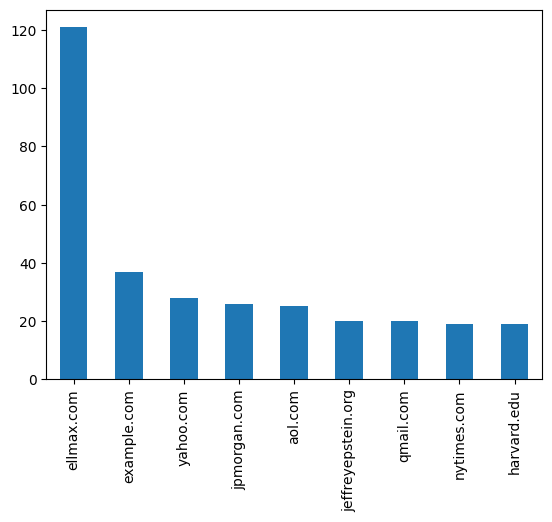

In [3]:
domain = [item.split('@')[1] for item in found]
domain_counts = pd.Series(domain).value_counts()
print(domain_counts)
domain_counts[1:10].plot(kind = 'bar')

Friday       836
Thursday     806
Wednesday    743
Monday       643
Tuesday      592
Saturday     550
Sunday       508
Name: count, dtype: int64


<Axes: >

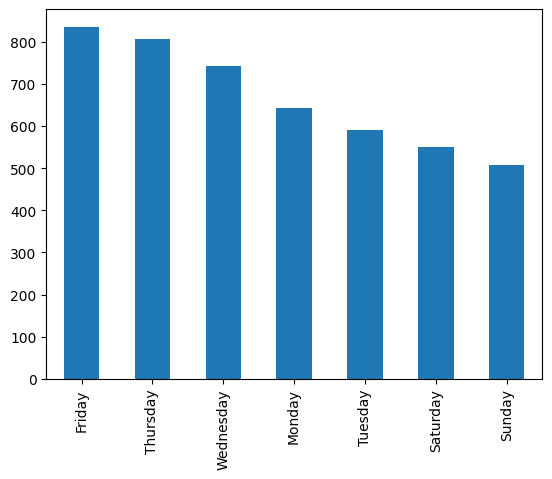

In [9]:
dates = pd.to_datetime(found, errors = 'coerce').dropna().day_name()
date_counts = dates.value_counts()
print(date_counts)
date_counts.plot(kind = 'bar')

516-922-9463    3
212-531-2858    2
212-335-9400    2
212-757-2323    2
302-739-3073    2
331-441-7021    2
212-533-3739    2
877-862-5384    2
888-596-1027    2
305-673-2756    1
917-749-8421    1
212-202-4604    1
212-442-8953    1
917-584-7675    1
212-210-1536    1
917-952-4052    1
646-448-6413    1
Name: count, dtype: int64


<Axes: >

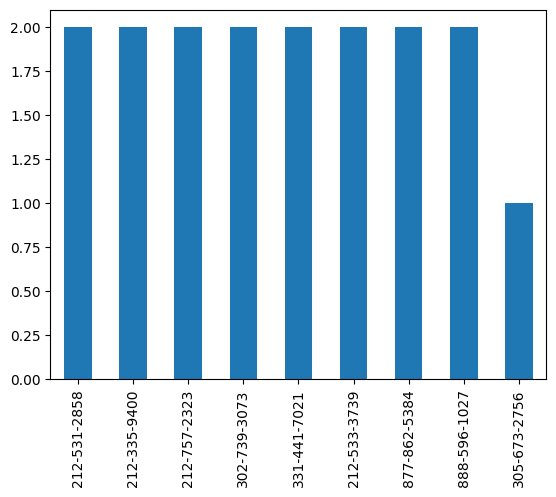

In [12]:
phone = []
for item in found:
    digits = re.sub(r'\D', '', item)
    phone.append(f"{digits[:3]}-{digits[3:6]}-{digits[6:10]}")
phone_counts = pd.Series(phone).value_counts()
print(phone_counts)
phone_counts[1:10].plot(kind = 'bar')

In [ ]:
# Date
# pattern = r'''
# \b(
# \d{1,2}/\d{1,2}/\d{2,4} |        # 12/31/2020
# \d{2,4}-\d{2}-\d{2} |              # 2020-12-31
# (?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)[a-z]*\s+\d{1,2},\s+\d{2,4}
# )\b
# '''
# Phone
# pattern = r'\b(?:\d{3}[-.]?\d{3}[-.]?\d{4}|\(\d{3}\)\s?\d{3}[-.]?\d{4}|\d{10})\b'
# URL
# pattern = r'https?://(?:www\.)?([a-zA-Z0-9.-]+\.[a-zA-Z]{2,})(?:/[^\s]*)?'